# Đồ án môn học: Khai phá dữ liệu (CO3029)
## Đề tài: Phân tích giỏ hàng (Market Basket Analysis) - Groceries Dataset

**Giai đoạn 1: Tiền xử lý dữ liệu và Phân tích khám phá (EDA)**

* **Mục tiêu:** Thực hiện quy trình làm sạch, biến đổi dữ liệu và thống kê mô tả để chuẩn bị "dữ liệu sạch" cho các thuật toán khai phá ở Giai đoạn 2.
* **Chuẩn đầu ra đáp ứng:** L.O.4 (Tiền xử lý dữ liệu) và L.O.4.1 (Mô tả thống kê dữ liệu).
* **Công cụ sử dụng:** Python (Pandas, NumPy, Matplotlib, Seaborn).

### Bước 1: Thiết lập và Tải dữ liệu
Trong bước này, nhóm sử dụng thư viện `kagglehub` để tải trực tiếp tập dữ liệu **Groceries Dataset** từ Kaggle. Việc này đảm bảo tính nhất quán và khả năng tái lập (reproducibility) của dự án khi chạy trên các máy khác nhau hoặc trong môi trường **Docker**.

* **Thư viện chính:** `pandas` xử lý bảng, `seaborn/matplotlib` trực quan hóa.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import pickle
from mlxtend.preprocessing import TransactionEncoder

path = kagglehub.dataset_download("heeraldedhia/groceries-dataset")
file_path = os.path.join(path, "Groceries_dataset.csv")
df = pd.read_csv(file_path)

print(f"Data Loaded. Shape: {df.shape}")

c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\DM\BTL\projec-folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Loaded. Shape: (38765, 3)


### Bước 2: Làm sạch dữ liệu (Data Cleaning)
Theo yêu cầu L.O.4.2 trong đề cương, dữ liệu thô cần được làm sạch để loại bỏ nhiễu. Các công việc thực hiện bao gồm:
1. Kiểm tra và xử lý giá trị thiếu (Null values).
2. Loại bỏ các dòng dữ liệu trùng lặp (Duplicates).
3. Chuẩn hóa dữ liệu văn bản: Loại bỏ khoảng trắng thừa bằng phương thức `strip()` để tránh trường hợp cùng một mặt hàng nhưng bị hiểu nhầm là hai loại khác nhau.

In [ ]:
# Standardize Date and Item Names
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['itemDescription'] = df['itemDescription'].str.strip().str.lower()

# Remove exact duplicates
df_clean = df.drop_duplicates().reset_index(drop=True)

# Create Transaction ID (Grouping by Member and Date)
df_clean['transaction_id'] = (
    df_clean['Member_number'].astype(str) + '_' +
    df_clean['Date'].dt.strftime('%Y%m%d')
)

print(f"Cleaning complete. Unique Transactions: {df_clean['transaction_id'].nunique()}")

Cleaning complete. Unique Transactions: 14963


### Bước 3: Phân tích khám phá dữ liệu (EDA)
Thực hiện các kỹ thuật thống kê mô tả (L.O.4.1) để hiểu rõ hơn về tập dữ liệu:
* Xác định các mặt hàng phổ biến nhất (Top 10 items).
* Quan sát xu hướng mua sắm theo thời gian để nhận diện các khung giờ hoặc ngày cao điểm.
* Việc này giúp đưa ra những nhận định sơ bộ (Hypothesis) trước khi thực hiện khai phá luật kết hợp ở Giai đoạn 2.

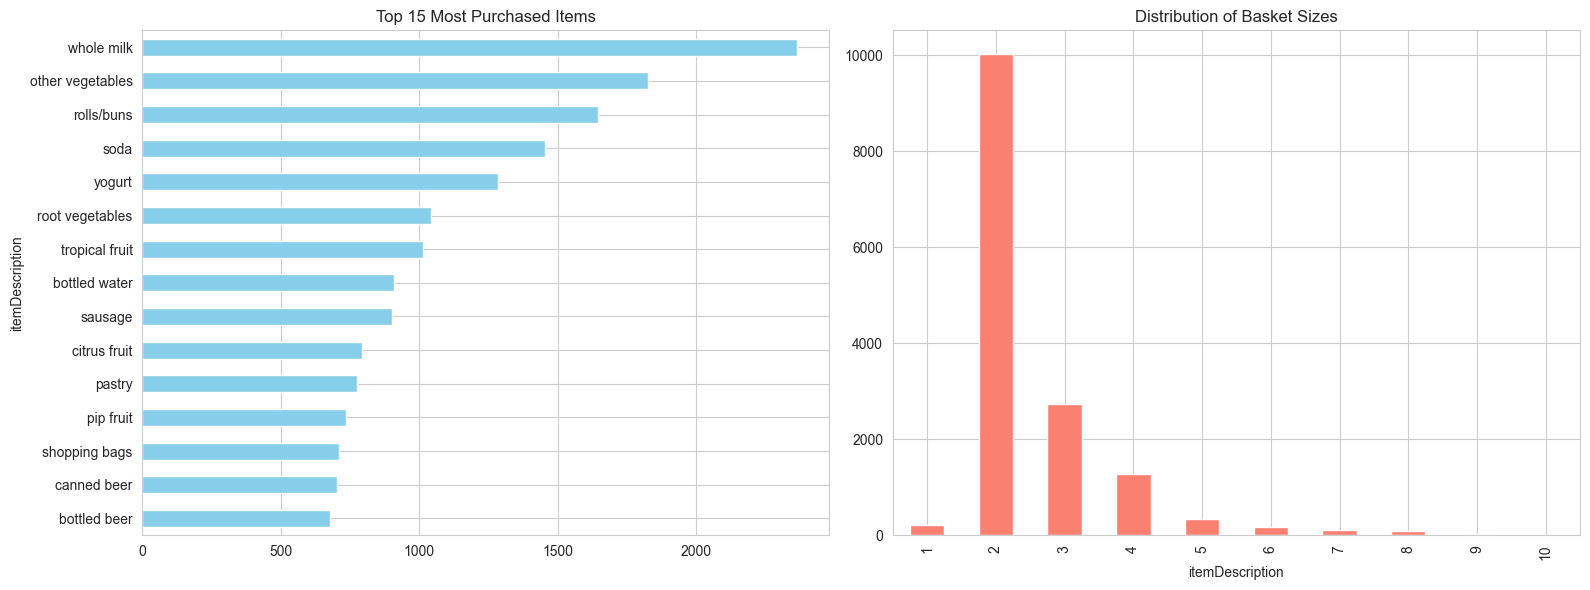

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Top 15 Items
df_clean['itemDescription'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='skyblue'
)
axes[0].set_title('Top 15 Most Purchased Items')

# Chart 2: Basket Size Distribution
basket_sizes = df_clean.groupby('transaction_id')['itemDescription'].count()
basket_sizes.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='salmon'
)
axes[1].set_title('Distribution of Basket Sizes')

plt.tight_layout()
plt.show()

### Bước 4: Biến đổi dữ liệu (Data Transformation)
Đây là bước quan trọng nhất trong tiền xử lý cho bài toán Market Basket Analysis (L.O.4.3). Dữ liệu dạng bảng (tabular) cần được chuyển đổi sang định dạng giao dịch (transactional format):
1. Nhóm các sản phẩm theo `Member_number` và `Date` để xác định một "giỏ hàng" duy nhất.
2. Chuyển đổi danh sách sản phẩm thành định dạng **One-hot encoding** (Ma trận nhị phân 0-1) bằng `pd.get_dummies()` hoặc `TransactionEncoder`. 
* Ma trận này là đầu vào bắt buộc cho thuật toán **Apriori** và **FP-Growth**.

In [ ]:
# Format 1: List of lists (for FP-Growth)
transactions = df_clean.groupby('transaction_id')['itemDescription'].apply(list).tolist()

# Format 2: One-hot matrix (for Apriori)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix ready. Shape: {basket_df.shape}")

Matrix ready. Shape: (14963, 167)


### Bước 5: Xuất dữ liệu đã xử lý
Để phục vụ cho **Giai đoạn 2 (Thành viên 2)**, dữ liệu sau khi biến đổi sẽ được lưu trữ dưới hai định dạng:
* `basket_matrix.csv`: Ma trận nhị phân dùng cho thuật toán Apriori.
* `transactions_list.pkl`: Danh sách các giao dịch dùng cho thuật toán FP-Growth.

*Lưu ý: Các file này đã được cấu hình trong `.gitignore` để tránh làm nặng Repository trên GitHub.*

In [ ]:
df_clean.to_csv('data/processed/groceries_cleaned.csv', index=False)
basket_df.to_csv('data/processed/basket_matrix.csv', index=False)

with open('artifacts/transactions_list.pkl', 'wb') as f:
    pickle.dump(transactions, f)

print("Complete.")

Complete.


**Kết luận Giai đoạn 1:** Dữ liệu đã được chuẩn bị sẵn sàng với **14,963 giao dịch** và **167 mặt hàng**. Chất lượng dữ liệu đảm bảo không còn nhiễu và đã ở định dạng tối ưu để thực hiện khai phá luật kết hợp.